# The Zero-Order-Hold trajectory leg for solar sailing

The Zero-Order-Hold (ZOH, parameterized by the *cut* parameter) solar-sail trajectory leg is implemented in `pykep` as {class}`pykep.leg.zoh_ss`. The method is described in {cite:p}`izzo2026zoh` as a ZOH $_\alpha$ transcription. Conceptually, this class extends the same forward-backward matching framework used by {class}`pykep.leg.zoh`, but specializes it to a 6D state and 2D sail-orientation controls.

Given an initial state $\mathbf{x}_0=[\mathbf r_0,\mathbf v_0]$, a final state $\mathbf{x}_f=[\mathbf r_f,\mathbf v_f]$, and a time grid $\{t_k\}_{k=0}^{N}$, the leg is partitioned into $N$ segments. On each segment $k$, the control is represented by
$$
\mathbf{u}_k=[\alpha_k,\beta_k],
$$
and the full control vector is
$$
\mathbf{u}=[\mathbf{u}_0,\mathbf{u}_1,\ldots,\mathbf{u}_{N-1}].
$$

A forward-backward shooting construction enforces continuity at the matching point, yielding the mismatch (defect) constraints and their analytical Jacobians with respect to states, controls, and time-grid variables.

We start with the required imports:

In [1]:
import pykep as pk
import heyoka as hy
import numpy as np
import pygmo as pg
from copy import deepcopy

#%matplotlib ipympl
%matplotlib inline

In [2]:
# Tolerances used in the numerical integration
# Lower tolerances are faster but less accurate (required tolerance depends on regime).
tol = 1e-10
tol_var = 1e-6

# Instantiate ZOH Taylor integrators for solar-sail dynamics (provided by pykep).
# Contract with leg.zoh_ss: state dimension = 6; first 2 parameters are controls;
# variational dynamics are first-order sensitivities w.r.t. state and controls.
ta_global = pk.ta.get_zoh_ss(tol)
ta_var_global = pk.ta.get_zoh_ss_var(tol_var)

# Non-dimensional units (the ZOH Taylor integrator expects MU=1 and sail flux at L=1).
MU = 139348062043.343e9  # MU of the fictitious ALTAIRA star (gtoc13)
L = 149597870.691e3  # reference radius (1 AU), where Altaira flux is defined
V = np.sqrt(MU / L)
TIME = L / V
ACC = V / TIME

# 1 - Validate the Zero-Order-Hold solar-sail leg
We first validate the implementation by comparing analytical gradients from {class}`pykep.leg.zoh_ss` against finite-difference estimates.

This section also illustrates the standard construction workflow: define boundary states, build controls and time grid, instantiate the leg, then query constraints and Jacobians.

We start with a helper function used for numerical differentiation:

In [3]:
# This assumes a copy of the leg because it mutates the object.
def compute_mismatch_constraints_n(leg_mod, state0, controls, state1, tgrid):
   leg_mod.tgrid = tgrid
   leg_mod.state0 = state0
   leg_mod.state1 = state1
   leg_mod.controls = controls
   return leg_mod.compute_mismatch_constraints()

We now instantiate a representative leg by selecting the number of segments, the cut, and the control vector in non-dimensional units.

In [4]:
# Leg random data
nseg = int(np.random.uniform(4, 20))
controls = np.random.uniform(-np.pi / 2, np.pi / 2, (2 * nseg,))
cut = np.random.uniform(0, 1)

# Non-dimensional test states and time grid
state0 = [1, 0, 0, 0, 1, 0]
state1 = [1, 0, 0, 0, 1, 0]
tgrid = np.linspace(0, 2 * np.pi, nseg + 1)

# Set integrator parameters
ta_global.pars[2] = 0.052059975027635791
ta_var_global.pars[2] = 0.052059975027635791

# Instantiate the leg
leg = pk.leg.zoh_ss(state0, controls.tolist(), state1, tgrid, cut=cut, tas=[ta_global, ta_var_global])

We now compute and store the analytical mismatch-constraint Jacobians:

In [5]:
grad_an_mc = leg.compute_mc_grad()

... and compare with numerical estimates. We use `pagmo` finite differences as a consistency check.

In [6]:
# Check on dmc/dx0
leg_copy = deepcopy(leg)
grad_num = pg.estimate_gradient(lambda x: compute_mismatch_constraints_n(leg_copy, x, leg_copy.controls, leg_copy.state1, leg_copy.tgrid), leg_copy.state0).reshape(6, -1)
np.linalg.norm(grad_num - grad_an_mc[0])

2.109824208559656e-08

In [7]:
# Check on dmc/dxf
leg_copy = deepcopy(leg)
grad_num = pg.estimate_gradient(lambda x: compute_mismatch_constraints_n(leg_copy, leg_copy.state0, leg_copy.controls, x, leg_copy.tgrid), leg.state1).reshape(6, -1)
np.linalg.norm(grad_num - grad_an_mc[1])

4.4744341961471071e-07

In [8]:
# Check on dmc/dcontrols
leg_copy = deepcopy(leg)
grad_num = pg.estimate_gradient(lambda x: compute_mismatch_constraints_n(leg_copy, leg_copy.state0, x, leg_copy.state1, leg_copy.tgrid), leg.controls, dx=1e-8).reshape(6, -1)
np.linalg.norm(grad_num - grad_an_mc[2])

4.8395911159187322e-07

In [9]:
# Check on dmc/dtgrid
leg_copy = deepcopy(leg)
grad_num = pg.estimate_gradient(lambda x: compute_mismatch_constraints_n(leg_copy, leg_copy.state0, leg_copy.controls, leg_copy.state1, x), leg.tgrid).reshape(6, -1)
np.linalg.norm(grad_num - grad_an_mc[3])

6.9013511268388899e-08

The differences are small and consistent with finite-difference truncation/roundoff errors. In practice, analytical Jacobians are preferable for accuracy and efficiency.

We can now visualize the stitched forward/backward trajectory segments, together with the planetary orbits.

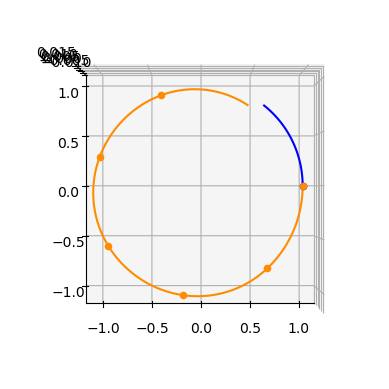

In [10]:
ax = pk.plot.make_3Daxis()
fwd, bck, success = leg.get_state_info(N=100)
for segment in fwd:
    ax.scatter(segment[0,0], segment[0,1], segment[0,2], c = 'blue') 
    ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'blue') 
for segment in bck:
    ax.scatter(segment[0,0], segment[0,1], segment[0,2], c = 'darkorange') 
    ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'darkorange') 

ax.view_init(90,-90)
